# 🏦 Loan Prediction — Exploratory Data Analysis
**Goal:** Predict whether a loan will be approved (Loan_Status = Y/N)

## Sections
1. Load & Inspect Data
2. Univariate Analysis
3. Bivariate / Target Analysis
4. Missing Value Treatment
5. Outlier Analysis
6. Correlation Heatmap
7. Key Insights & Conclusions
8. Train/Test Split

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


RANDOM_STATE = 42
df = pd.read_csv('../data/raw/train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Load & Inspect Data

In [2]:
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Basic Stats ---')
df.describe(include='all')


--- Data Types ---
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

--- Basic Stats ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN



🔍 Missing Values:
                  Missing Count  Missing %
Credit_History               50       8.14
Self_Employed                32       5.21
LoanAmount                   22       3.58
Dependents                   15       2.44
Loan_Amount_Term             14       2.28
Gender                       13       2.12
Married                       3       0.49


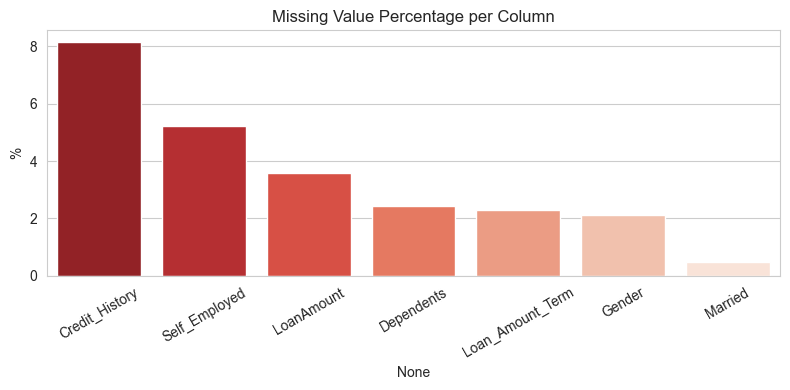

In [3]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('\n🔍 Missing Values:')
print(missing_df)

# Visualise
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='Reds_r')
plt.title('Missing Value Percentage per Column')
plt.xticks(rotation=30)
plt.ylabel('%')
plt.tight_layout()
plt.savefig('../reports/missing_values.png', dpi=150)
plt.show()

## 2. Univariate Analysis

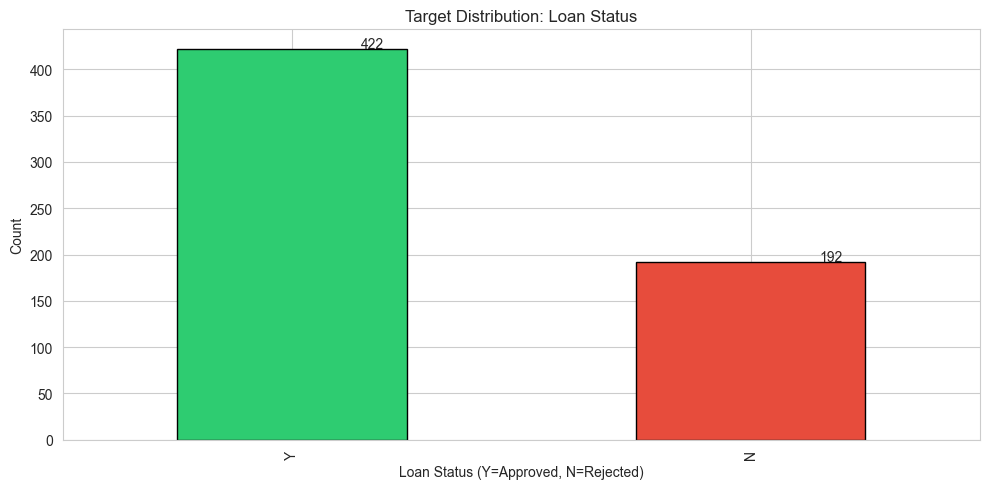

Y    0.687
N    0.313
Name: Loan_Status, dtype: float64


In [4]:
# Target distribution
ax = df['Loan_Status'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black')
plt.title('Target Distribution: Loan Status')
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.4, p.get_height() + 1))
plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=150)
plt.show()
print(df['Loan_Status'].value_counts(normalize=True).round(3))

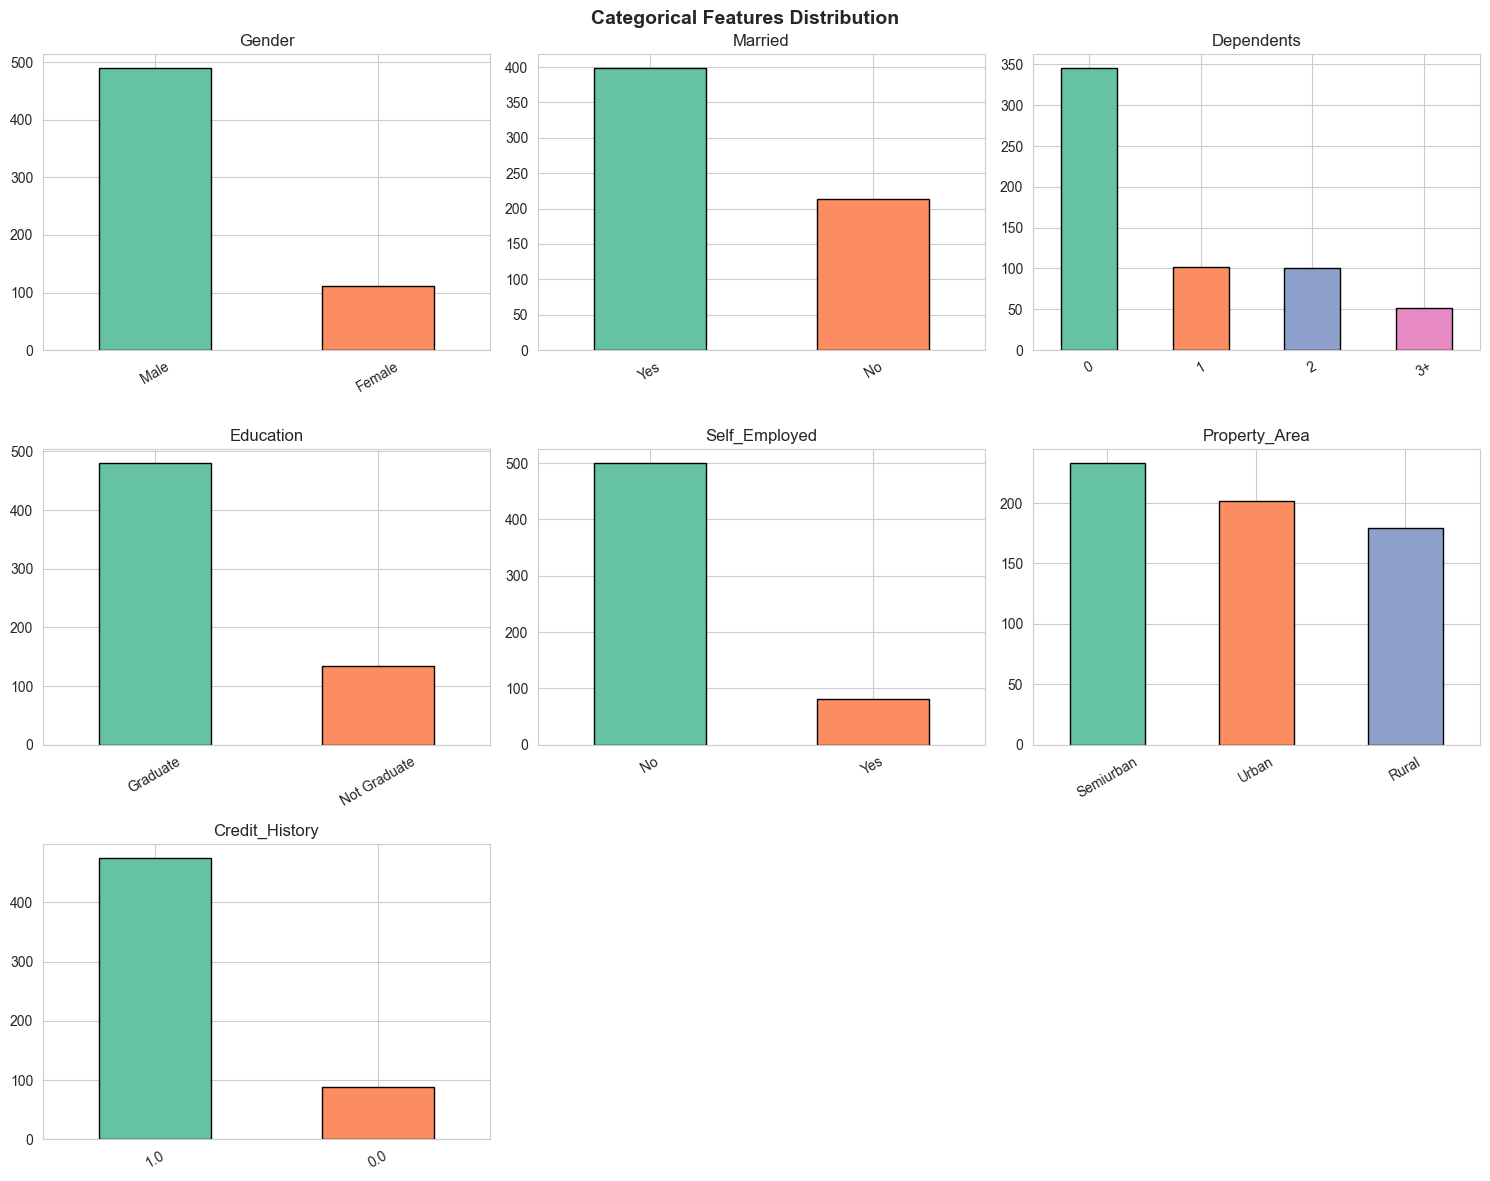

In [5]:
# Categorical features
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Credit_History']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2'), edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Categorical Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/categorical_dist.png', dpi=150)
plt.show()

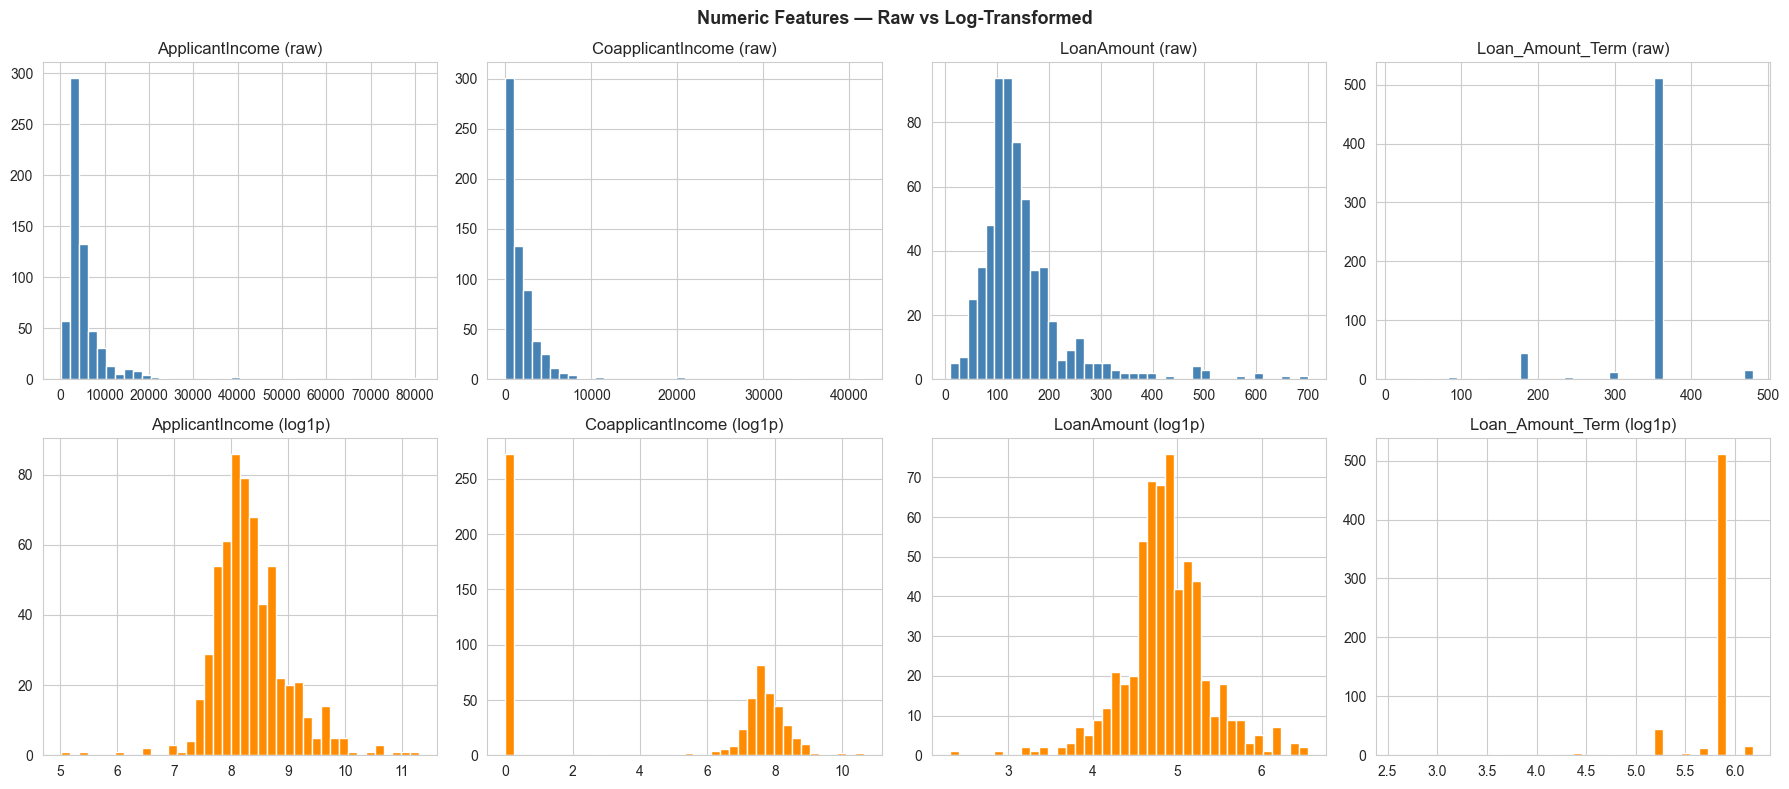

In [6]:
# Numeric features — distribution + log transform
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} (raw)')
    axes[1, i].hist(np.log1p(df[col].dropna()), bins=40, color='darkorange', edgecolor='white')
    axes[1, i].set_title(f'{col} (log1p)')
plt.suptitle('Numeric Features — Raw vs Log-Transformed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/numeric_dist.png', dpi=150)
plt.show()

## 3. Bivariate / Target Analysis

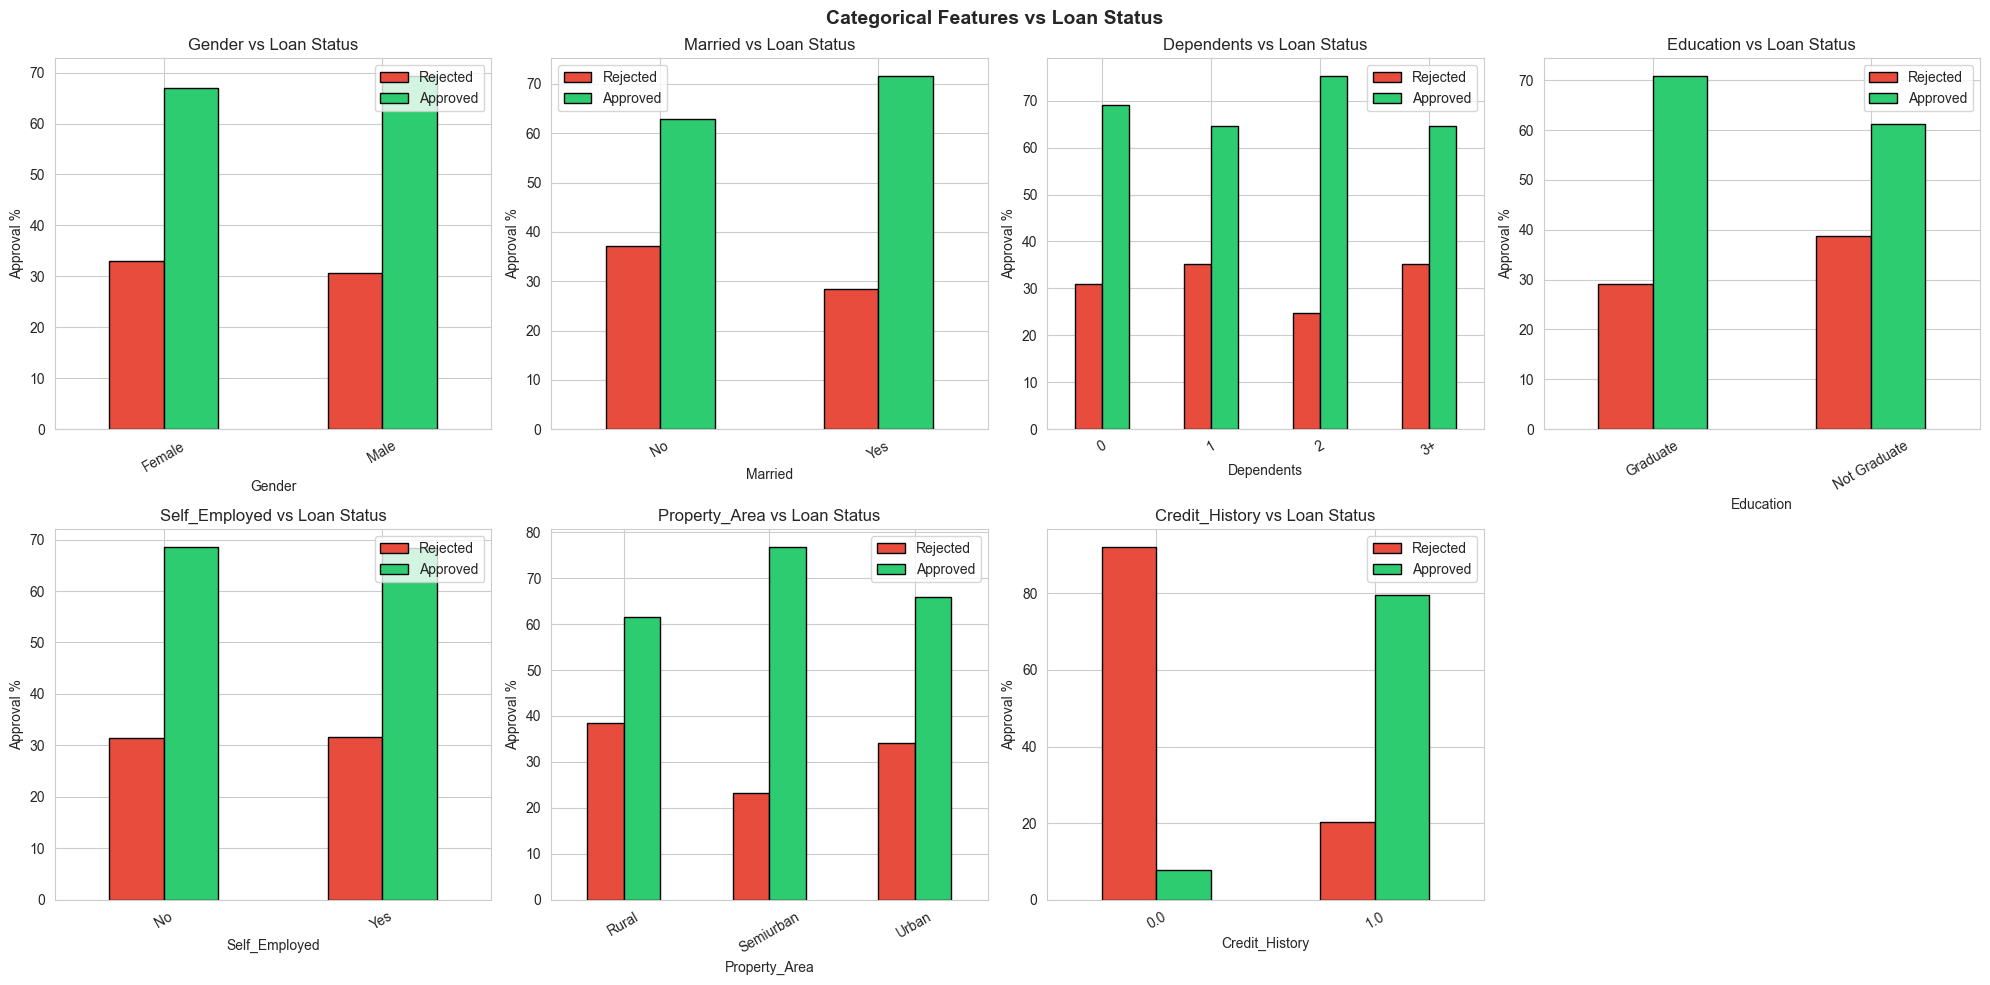

In [7]:
# Categorical vs Target
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c','#2ecc71'], edgecolor='black')
    axes[i].set_title(f'{col} vs Loan Status')
    axes[i].set_ylabel('Approval %')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Rejected','Approved'])
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Categorical Features vs Loan Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/cat_vs_target.png', dpi=150)
plt.show()

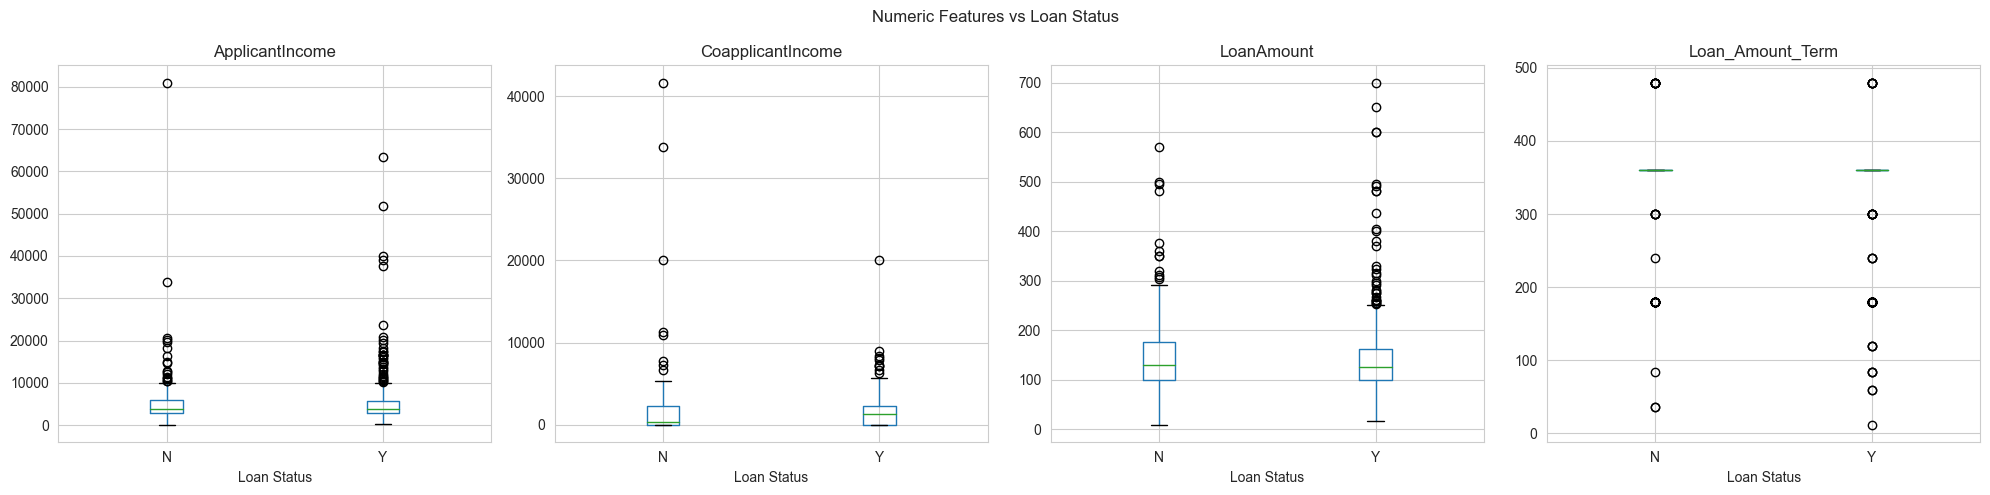

In [8]:
# Numeric vs Target — BoxPlots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Loan_Status', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Loan Status')
plt.suptitle('Numeric Features vs Loan Status')
plt.tight_layout()
plt.savefig('../reports/num_vs_target.png', dpi=150)
plt.show()

## 4. Missing Value Treatment

In [9]:
df_clean = df.copy()

# Categorical: fill with mode
for col in ['Gender','Married','Dependents','Self_Employed','Credit_History']:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Numeric: fill with median
df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median(), inplace=True)
df_clean['Loan_Amount_Term'].fillna(df_clean['Loan_Amount_Term'].mode()[0], inplace=True)

print('Missing after treatment:')
print(df_clean.isnull().sum())

Missing after treatment:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## 5. Outlier Analysis

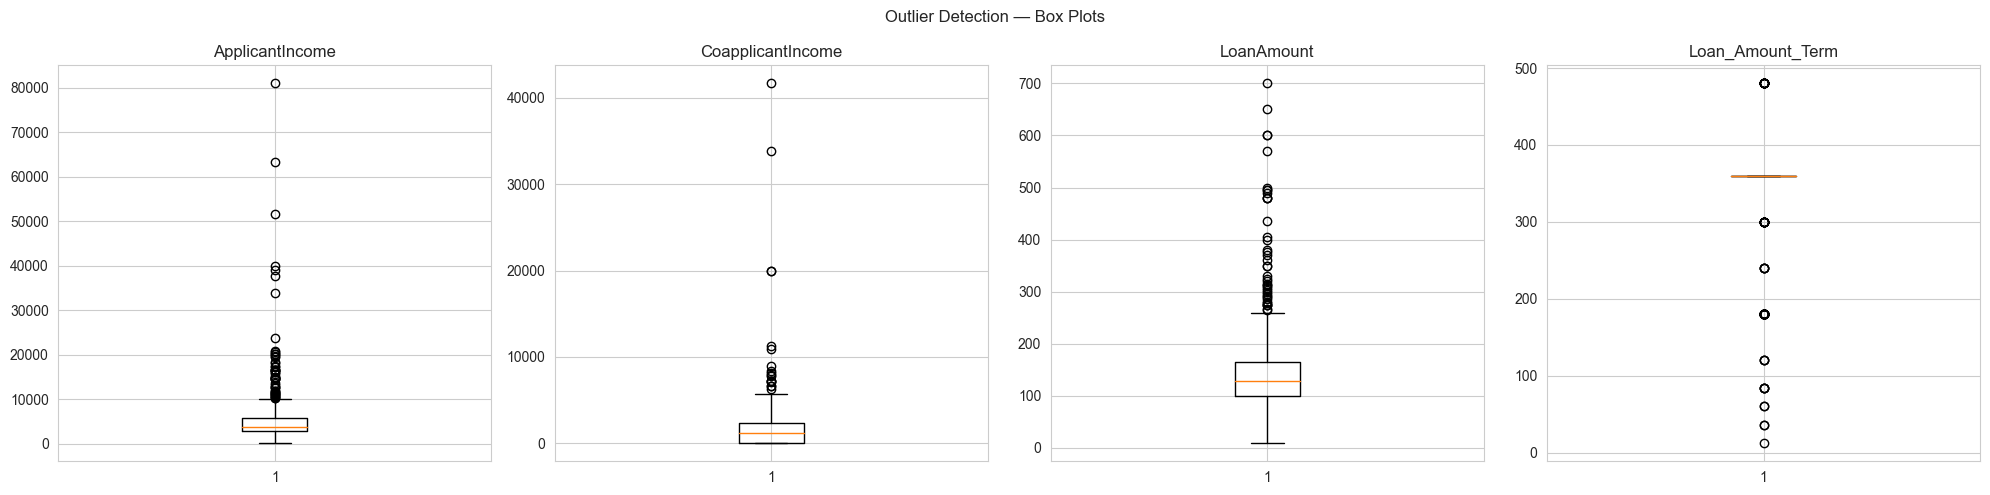

Outliers capped ✅


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Outlier Detection — Box Plots')
plt.tight_layout()
plt.savefig('../reports/outliers.png', dpi=150)
plt.show()

# Cap using IQR
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in ['ApplicantIncome','CoapplicantIncome','LoanAmount']:
    df_clean[col] = cap_outliers(df_clean[col])
print('Outliers capped ✅')

## 6. Correlation Heatmap

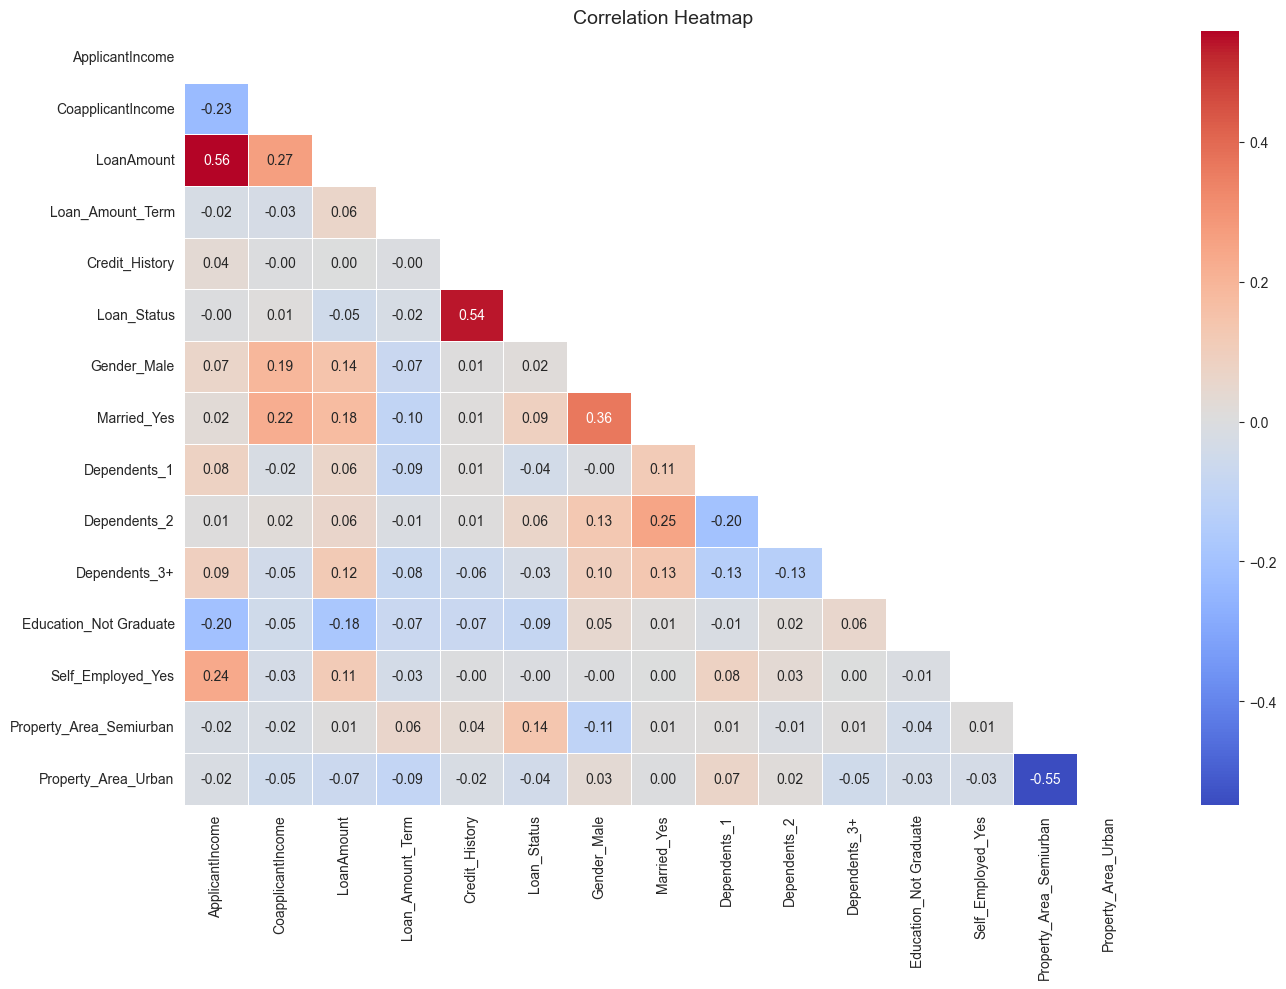

In [11]:
# Encode for correlation
df_enc = df_clean.copy()
df_enc['Loan_Status'] = (df_enc['Loan_Status'] == 'Y').astype(int)
cat_encode = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']
df_enc = pd.get_dummies(df_enc, columns=cat_encode, drop_first=True)
df_enc.drop(columns=['Loan_ID'], inplace=True)

plt.figure(figsize=(14, 10))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()

## 7. Key Insights

### 📌 Key Insights from EDA

| # | Insight |
|---|--------|
| 1 | **Class imbalance**: ~69% loans approved vs 31% rejected |
| 2 | **Credit History** is the strongest predictor — applicants with credit history have ~80% approval rate |
| 3 | **ApplicantIncome & LoanAmount** are heavily right-skewed — log transform recommended |
| 4 | **Graduates** have higher approval rates than non-graduates |
| 5 | **Married** applicants tend to get more approvals |
| 6 | **Semi-Urban** property area has the highest approval rate |
| 7 | **LoanAmount** has ~22 missing values — median imputation used |
| 8 | **Outliers** exist in Income and LoanAmount — IQR capping applied |

## 8. Train / Test Split

In [ ]:
# Save cleaned data and split
import os
os.makedirs('../data/processed', exist_ok=True)

df_clean.to_csv('../data/processed/cleaned.csv', index=False)

X = df_enc.drop(columns=['Loan_Status'])
y = df_enc['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Train class balance:\n{y_train.value_counts(normalize=True).round(3)}')

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
print(' Splits saved to data/processed/')

Train size : (491, 14)
Test size  : (123, 14)
Train class balance:
1    0.686
0    0.314
Name: Loan_Status, dtype: float64
✅ Splits saved to data/processed/
